In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [5]:
from google.colab import files
uploaded = files.upload()

Saving part_2_cnn_computer_vision-20260515T065039Z-3-001.zip to part_2_cnn_computer_vision-20260515T065039Z-3-001 (1).zip


In [7]:
import zipfile, os

with zipfile.ZipFile('part_2_cnn_computer_vision-20260515T065039Z-3-001.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset')

print(os.listdir('dataset'))

['part_2_cnn_computer_vision']


In [8]:
dataset_path = 'dataset'
for item in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, item)
    if os.path.isdir(full_path):
        print(f'{item}: {len(os.listdir(full_path))} files')

part_2_cnn_computer_vision: 4 files


In [9]:
for root, dirs, files_list in os.walk('dataset'):
    level = root.replace('dataset', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level >= 1:
        print(f'{indent}  → {len(files_list)} files')

dataset/
  part_2_cnn_computer_vision/
    → 3 files
    images/
      → 1 files
      normal/
        → 120 files
      stain/
        → 120 files
      dent/
        → 120 files
      scratch/
        → 120 files


In [10]:
dataset_path = 'dataset/part_2_cnn_computer_vision/images'
class_folders = ['normal', 'stain', 'dent', 'scratch']

for cls in class_folders:
    count = len(os.listdir(f'{dataset_path}/{cls}'))
    print(f'{cls}: {count} images')

normal: 120 images
stain: 120 images
dent: 120 images
scratch: 120 images


In [11]:
IMG_SIZE = (64, 64)
X = []
y = []

for cls in class_folders:
    folder_path = f'{dataset_path}/{cls}'
    for img_file in os.listdir(folder_path):
        if img_file.startswith('.'):
            continue
        img_path = os.path.join(folder_path, img_file)
        img = Image.open(img_path).convert('RGB').resize(IMG_SIZE)
        X.append(np.array(img) / 255.0)
        y.append(cls)

X = np.array(X)
y = np.array(y)
print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (480, 64, 64, 3)
y shape: (480,)


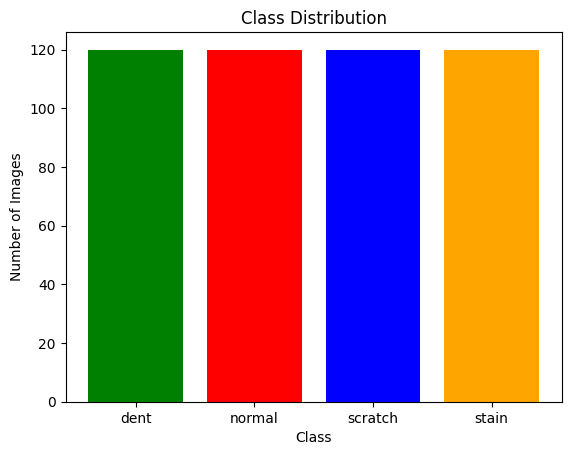

In [12]:
unique, counts = np.unique(y, return_counts=True)
plt.bar(unique, counts, color=['green','red','blue','orange'])
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.show()

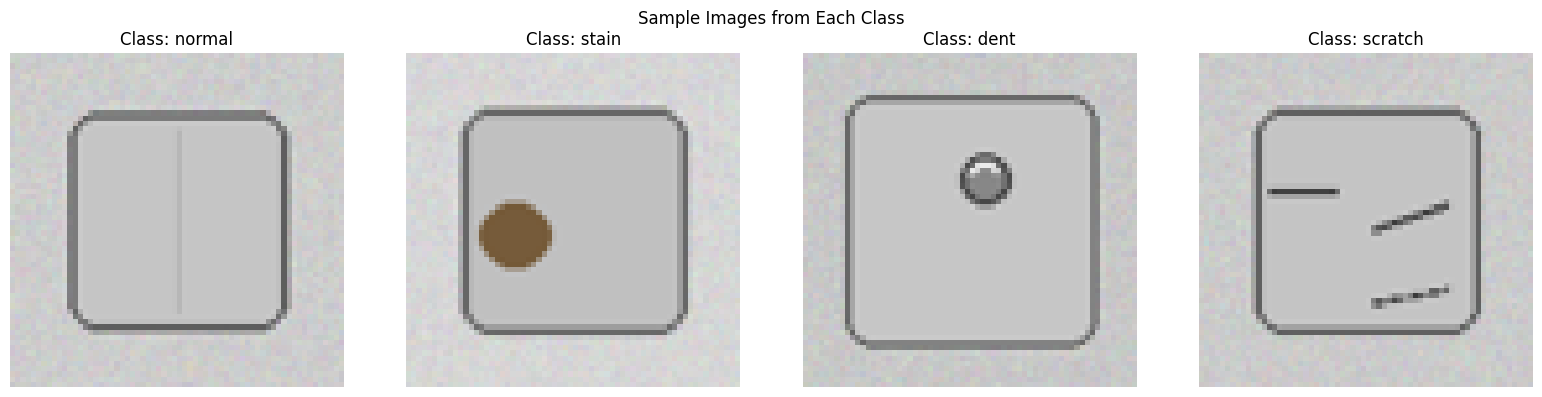

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, cls in enumerate(class_folders):
    idx = list(y).index(cls)
    axes[i].imshow(X[idx])
    axes[i].set_title(f'Class: {cls}')
    axes[i].axis('off')
plt.suptitle('Sample Images from Each Class')
plt.tight_layout()
plt.show()

## Task 3 : Image preprocessing

In [14]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = tf.keras.utils.to_categorical(y_encoded, num_classes=4)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y_encoded
)
print('Train images:', X_train.shape[0])
print('Test images:', X_test.shape[0])

Train images: 384
Test images: 96


# Build CNN Model

In [15]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 3)),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,716 (2.61 MB)

 Trainable params: 683,716 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

# Task -5 Model Training and Evaluation

In [16]:
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 236ms/step - accuracy: 0.2345 - loss: 1.4248 - val_accuracy: 0.2468 - val_loss: 1.3948
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 221ms/step - accuracy: 0.2606 - loss: 1.3946 - val_accuracy: 0.2208 - val_loss: 1.3903
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 330ms/step - accuracy: 0.2508 - loss: 1.3878 - val_accuracy: 0.2208 - val_loss: 1.3842
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 221ms/step - accuracy: 0.2671 - loss: 1.3807 - val_accuracy: 0.2987 - val_loss: 1.3793
Epoch 5/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 205ms/step - accuracy: 0.2997 - loss: 1.3665 - val_accuracy: 0.2468 - val_loss: 1.3335
Epoch 6/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 205ms/step - accuracy: 0.4039 - loss: 1.2591 - val_accuracy: 0.5455 - val_loss: 1.1902
Epoch 7/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 206ms/step - accuracy: 0.5570 - loss: 1.0343 - val_accuracy: 0.7013 - val_loss: 0.8736
Epoch 8/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 206ms/step - accuracy: 0.6352 - loss: 0.9244 - val_accuracy: 0.

In [17]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {test_acc*100:.2f}%')

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9062 - loss: 0.2402
Test Accuracy: 90.62%


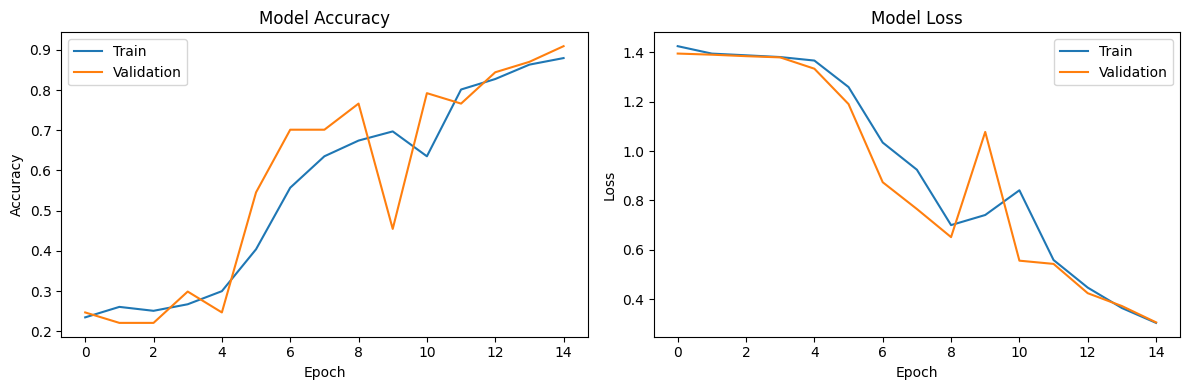

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


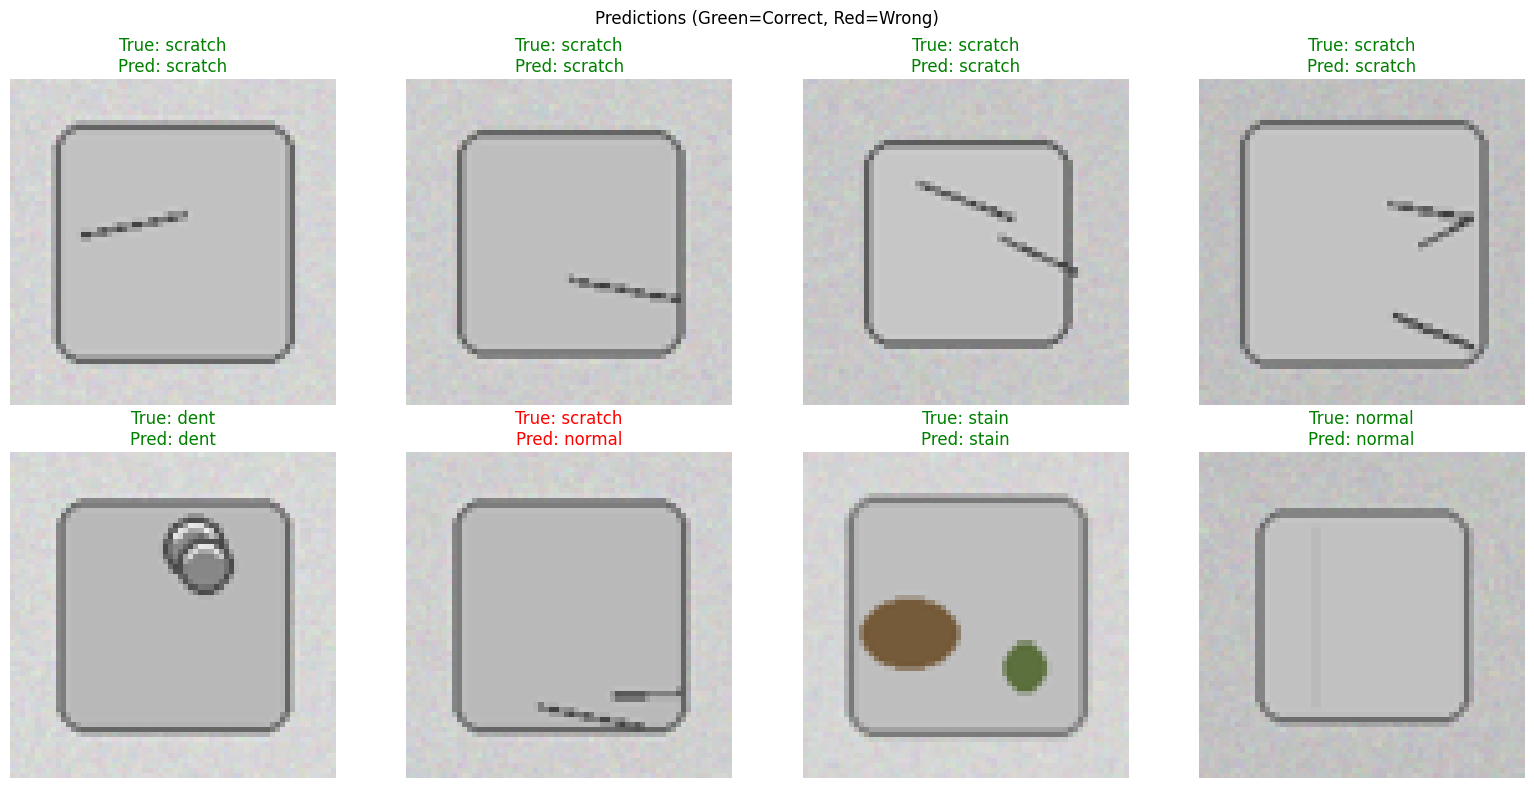

In [19]:
y_pred = model.predict(X_test[:8])
y_pred_classes = le.inverse_transform(np.argmax(y_pred, axis=1))
y_true_classes = le.inverse_transform(np.argmax(y_test[:8], axis=1))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_test[i])
    color = 'green' if y_pred_classes[i] == y_true_classes[i] else 'red'
    ax.set_title(f'True: {y_true_classes[i]}\nPred: {y_pred_classes[i]}', color=color)
    ax.axis('off')
plt.suptitle('Predictions (Green=Correct, Red=Wrong)')
plt.tight_layout()
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


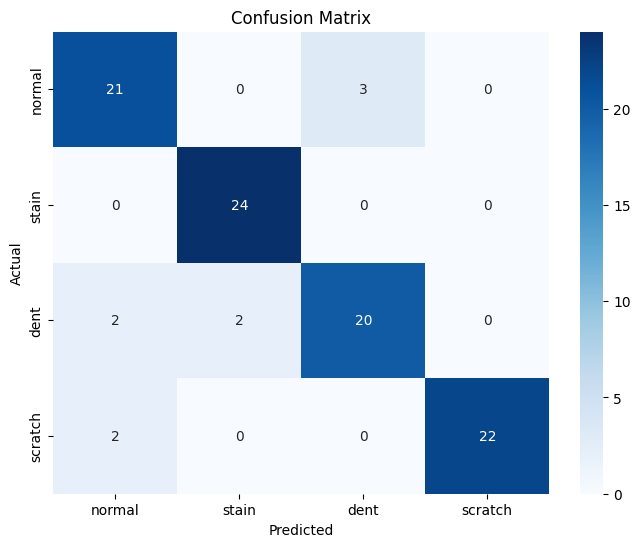

              precision    recall  f1-score   support

      normal       0.84      0.88      0.86        24
       stain       0.92      1.00      0.96        24
        dent       0.87      0.83      0.85        24
     scratch       1.00      0.92      0.96        24

    accuracy                           0.91        96
   macro avg       0.91      0.91      0.91        96
weighted avg       0.91      0.91      0.91        96



In [21]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
y_pred_all = model.predict(X_test)
y_pred_classes_all = np.argmax(y_pred_all, axis=1)
y_true_classes_all = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes_all, y_pred_classes_all)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_folders,
            yticklabels=class_folders)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(y_true_classes_all, y_pred_classes_all, target_names=class_folders))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


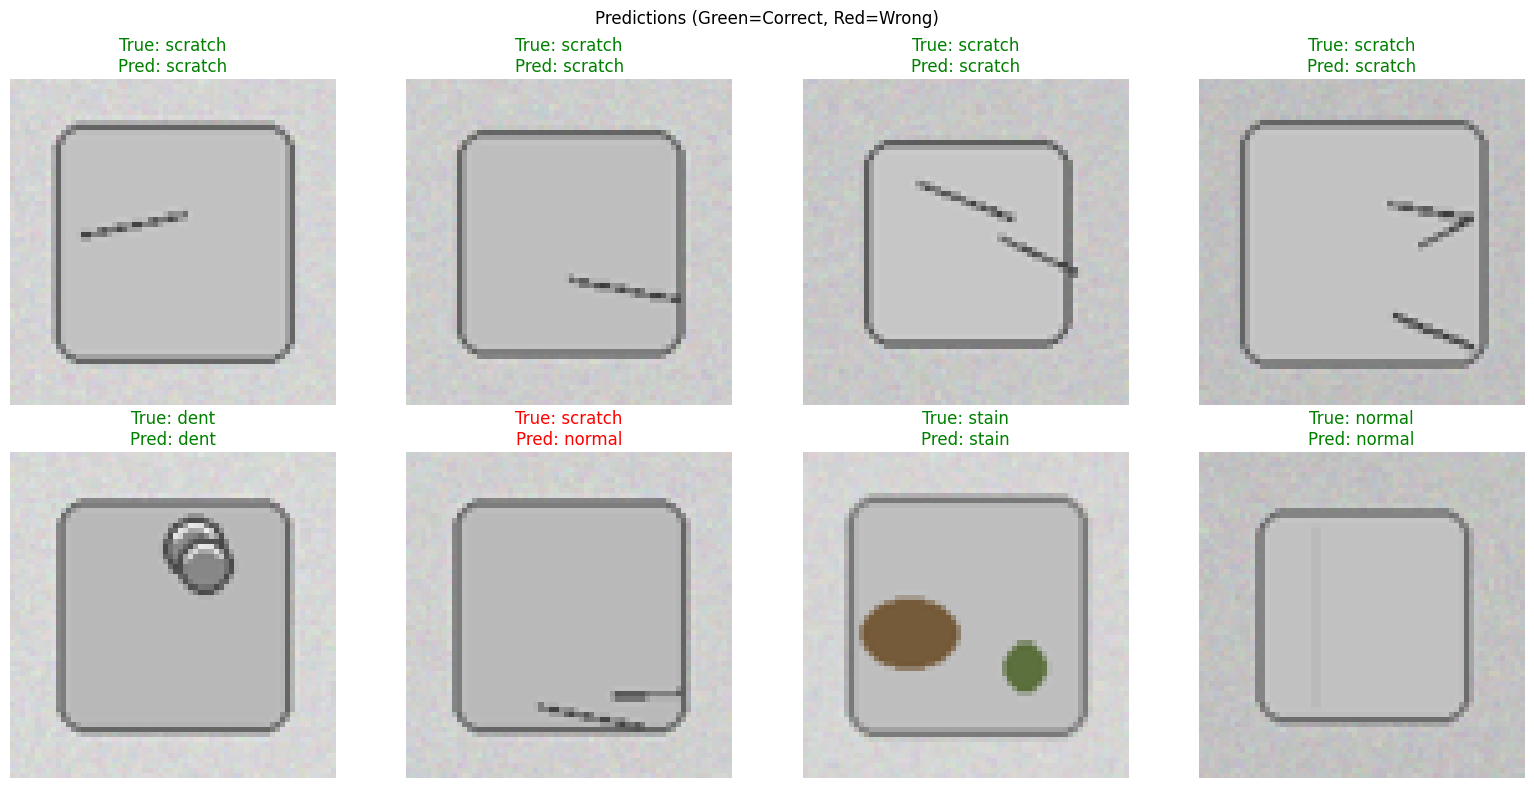

In [22]:
y_pred = model.predict(X_test[:8])
y_pred_classes = le.inverse_transform(np.argmax(y_pred, axis=1))
y_true_classes = le.inverse_transform(np.argmax(y_test[:8], axis=1))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_test[i])
    color = 'green' if y_pred_classes[i] == y_true_classes[i] else 'red'
    ax.set_title(f'True: {y_true_classes[i]}\nPred: {y_pred_classes[i]}', color=color)
    ax.axis('off')
plt.suptitle('Predictions (Green=Correct, Red=Wrong)')
plt.tight_layout()
plt.show()

## Task 6: CNN Concept Explanation

**What is Convolution?**
A small filter slides over the image to detect features like edges and textures.

**Why is Pooling used?**
Pooling reduces image size while keeping important features. It makes the model faster and prevents overfitting.

**Why is ReLU used?**
ReLU removes negative values so the model can learn complex patterns quickly.

**Why CNNs are better than regular networks?**
CNNs look at groups of pixels together so they understand shapes and patterns much better than regular networks which treat each pixel separately.

## Task 7: Business Use Case - Manufacturing

- Cameras capture product images on production line
- CNN classifies each product as normal, scratch, dent or stain
- Defective products removed automatically
- Reduces human error and saves time
- Example: Car factories inspecting body panels automatically without human inspectors

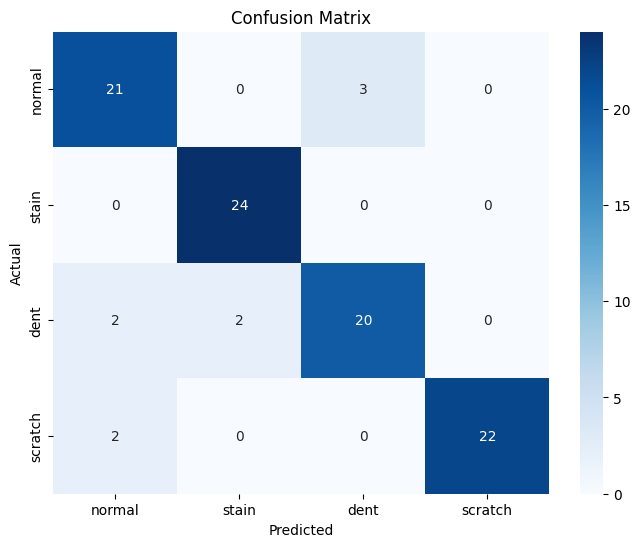

Saved!


In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true_classes_all, y_pred_classes_all)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_folders,
            yticklabels=class_folders)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('confusion_matrix.png')
plt.show()
print('Saved!')

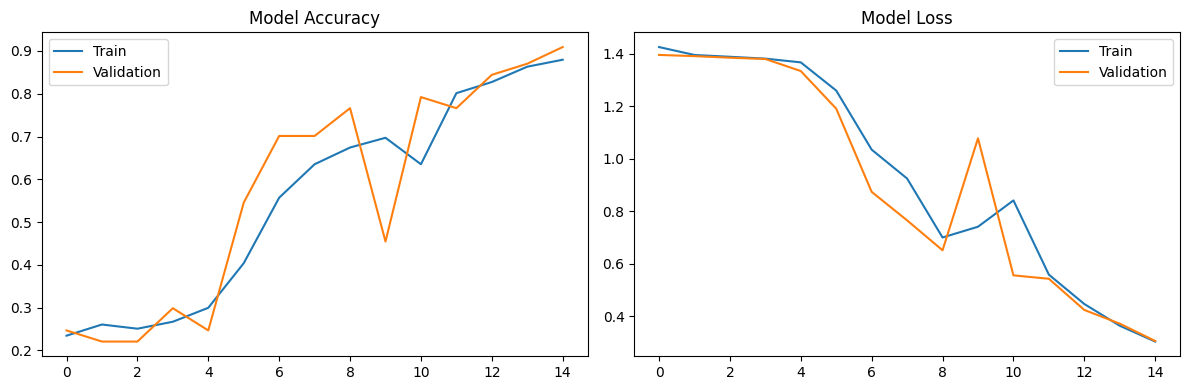

Saved!


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('accuracy_loss_curves.png')
plt.show()
print('Saved!')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step


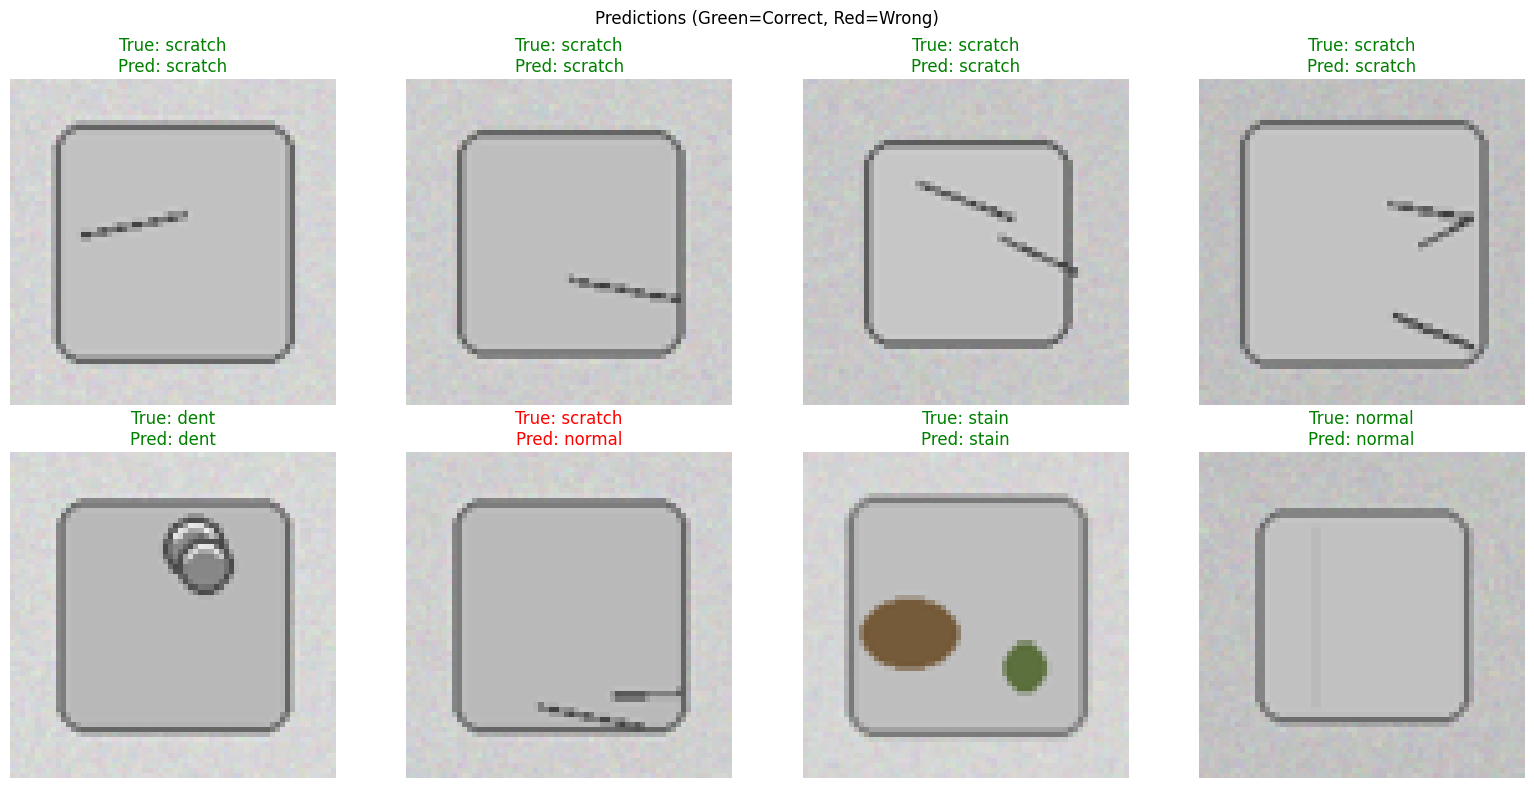

Saved!


In [25]:
y_pred = model.predict(X_test[:8])
y_pred_classes = le.inverse_transform(np.argmax(y_pred, axis=1))
y_true_classes = le.inverse_transform(np.argmax(y_test[:8], axis=1))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_test[i])
    color = 'green' if y_pred_classes[i] == y_true_classes[i] else 'red'
    ax.set_title(f'True: {y_true_classes[i]}\nPred: {y_pred_classes[i]}', color=color)
    ax.axis('off')
plt.suptitle('Predictions (Green=Correct, Red=Wrong)')
plt.tight_layout()
plt.savefig('prediction_outputs.png')
plt.show()
print('Saved!')

In [26]:
from google.colab import files

files.download('confusion_matrix.png')
files.download('accuracy_loss_curves.png')
files.download('prediction_outputs.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>